# Analyze data

Offline analysis of `cw_odmr.py run` datasets saved in the data directory (`D:\cw_odmr\`).
No live instrument connections needed here -- everything comes from the saved
`.csv`/`.npy`/metadata files. Shared analysis is factored into functions below so it can
be run against multiple datasets (`second`, `third`, ...) without repeating code.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

from hp8673h import HP8673H

DATA_DIR = "D:/cw_odmr"

In [2]:
def _fine_sweep_result(run_name):
    """estimate_q() result dict for a run's saved fine sweep, with no printing/plotting."""
    run_path = f"{DATA_DIR}/{run_name}"
    fine = np.genfromtxt(f"{run_path}/{run_name}_resonance_fine.csv", delimiter=",", names=True)
    return HP8673H.estimate_q(fine["frequency_hz"], fine["power_dbm"])


def _waveform_stats(run_name):
    """(seg_mean, seg_std, elapsed_s) for a run's saved waveform, with no printing/plotting."""
    run_path = f"{DATA_DIR}/{run_name}"
    waveform = np.load(f"{run_path}/{run_name}.npy")
    timetable_s = np.load(f"{run_path}/{run_name}_timetable.npy")
    elapsed_s = timetable_s - timetable_s[0]
    seg_mean = waveform.mean(axis=1)
    seg_std = waveform.std(axis=1)
    return seg_mean, seg_std, elapsed_s


def _bg_waveform_stats(run_name):
    """
    (seg_mean, seg_std) for a run's saved background (`_bg`, RF off) waveform,
    or None if this run has no saved background acquisition.
    """
    run_path = f"{DATA_DIR}/{run_name}"
    bg_path = f"{run_path}/{run_name}_bg.npy"
    if not os.path.exists(bg_path):
        return None
    waveform = np.load(bg_path)
    return waveform.mean(axis=1), waveform.std(axis=1)


def find_run_names():
    """
    Run folder names directly under DATA_DIR that look like a complete
    `cw_odmr.py run` dataset (have both a saved waveform and a fine-sweep
    CSV) -- skips `logs/` and anything else that doesn't match.
    """
    names = []
    for entry in sorted(os.listdir(DATA_DIR)):
        run_path = f"{DATA_DIR}/{entry}"
        if not os.path.isdir(run_path):
            continue
        if not os.path.exists(f"{run_path}/{entry}.npy"):
            continue
        if not os.path.exists(f"{run_path}/{entry}_resonance_fine.csv"):
            continue
        names.append(entry)
    return names

## Resonance (fine sweep)

Same depth/FWHM/Q methodology as `cw_odmr.py`'s `resonance_sweep()` --
`HP8673H.estimate_q()` is a `@staticmethod`, so it can be run directly on the saved fine-
sweep data with no instrument connection.

In [3]:
def analyze_resonance(run_name):
    run_path = f"{DATA_DIR}/{run_name}"
    fine = np.genfromtxt(f"{run_path}/{run_name}_resonance_fine.csv", delimiter=",", names=True)
    fine_freqs_hz = fine["frequency_hz"]
    fine_power_dbm = fine["power_dbm"]

    result = _fine_sweep_result(run_name)
    depth_db = result["baseline_dbm"] - result["dip_dbm"]

    print(f"{run_name}: f0 = {result['f0_hz']/1e9:.5f} GHz")
    print(f"{run_name}: dip = {result['dip_dbm']:.2f} dBm, baseline = {result['baseline_dbm']:.2f} dBm")
    print(f"{run_name}: depth = {depth_db:.2f} dB")
    print(f"{run_name}: FWHM = {result['fwhm_hz']/1e6:.3f} MHz, Q ~= {result['Q']:.0f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(fine_freqs_hz / 1e9, fine_power_dbm, ".-", ms=3, label="fine sweep")
    ax.axvline(result["f0_hz"] / 1e9, color="C1", ls="--", label=f"f0 = {result['f0_hz']/1e9:.5f} GHz")
    ax.axhline(result["baseline_dbm"], color="gray", ls=":", lw=1, label="baseline")
    ax.annotate(
        f"depth = {depth_db:.2f} dB",
        xy=(result["f0_hz"] / 1e9, result["dip_dbm"]),
        xytext=(0, -25), textcoords="offset points",
        ha="center", arrowprops=dict(arrowstyle="->"),
    )
    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel("power (dBm)")
    ax.set_title(f"{run_name}: fine resonance sweep")
    ax.legend()
    plt.show()

    return result

## Scope waveform (500 segments)

For each segment, compute its average value and standard deviation (scalars per
segment), then look at how those evolve across the ~50s acquisition
(`<run>_timetable.npy` gives each segment's trigger time) for any drift/trend.

In [4]:
def analyze_waveform(run_name):
    seg_mean, seg_std, elapsed_s = _waveform_stats(run_name)

    print(f"{run_name}: {len(seg_mean)} segments")
    print(f"{run_name}: average value across all {len(seg_mean)} segments: "
          f"{seg_mean.mean():.5f} V (segment-to-segment std of that average: {seg_mean.std():.5f} V)")
    print(f"{run_name}: average within-segment std: {seg_std.mean():.5f} V "
          f"(std of that std across segments: {seg_std.std():.5f} V)")

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    axes[0].plot(elapsed_s, seg_mean, ".", ms=3)
    mean_fit = np.polyfit(elapsed_s, seg_mean, 1)
    axes[0].plot(elapsed_s, np.polyval(mean_fit, elapsed_s), "C1--",
                 label=f"linear fit: slope = {mean_fit[0]*1e3:.4f} mV/s")
    axes[0].set_ylabel("segment average (V)")
    axes[0].set_title(f"{run_name}: per-segment average and std vs. acquisition time")
    axes[0].legend()

    axes[1].plot(elapsed_s, seg_std, ".", ms=3, color="C2")
    std_fit = np.polyfit(elapsed_s, seg_std, 1)
    axes[1].plot(elapsed_s, np.polyval(std_fit, elapsed_s), "C1--",
                 label=f"linear fit: slope = {std_fit[0]*1e3:.4f} mV/s")
    axes[1].set_xlabel("elapsed time (s)")
    axes[1].set_ylabel("segment std (V)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"{run_name}: average trend: {mean_fit[0]*1e3:+.4f} mV/s over {elapsed_s[-1]:.1f} s "
          f"(total change {mean_fit[0]*elapsed_s[-1]*1e3:+.4f} mV)")
    print(f"{run_name}: std trend: {std_fit[0]*1e3:+.4f} mV/s over {elapsed_s[-1]:.1f} s "
          f"(total change {std_fit[0]*elapsed_s[-1]*1e3:+.4f} mV)")

    return seg_mean, seg_std, elapsed_s

## `second/`

second: f0 = 2.67525 GHz
second: dip = -62.11 dBm, baseline = -47.88 dBm
second: depth = 14.24 dB
second: FWHM = 14.350 MHz, Q ~= 186


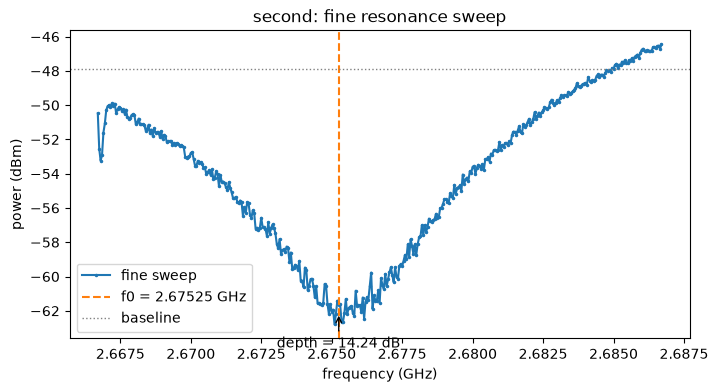

In [5]:
_ = analyze_resonance("second")

second: 500 segments
second: average value across all 500 segments: -0.01422 V (segment-to-segment std of that average: 0.00178 V)
second: average within-segment std: 0.01303 V (std of that std across segments: 0.00026 V)


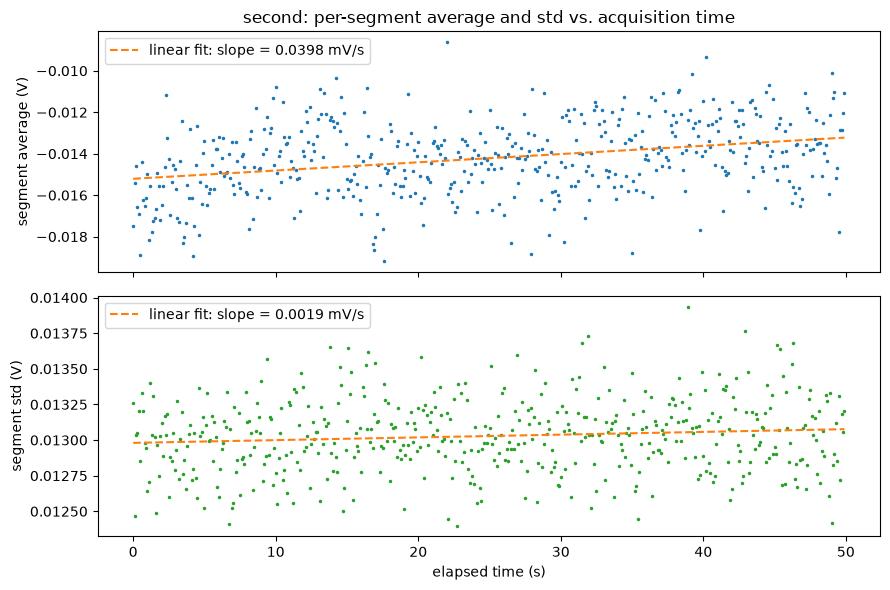

second: average trend: +0.0398 mV/s over 49.9 s (total change +1.9842 mV)
second: std trend: +0.0019 mV/s over 49.9 s (total change +0.0961 mV)


In [6]:
_ = analyze_waveform("second")

## `third/`

third: f0 = 2.20660 GHz
third: dip = -62.15 dBm, baseline = -49.11 dBm
third: depth = 13.04 dB
third: FWHM = 14.250 MHz, Q ~= 155


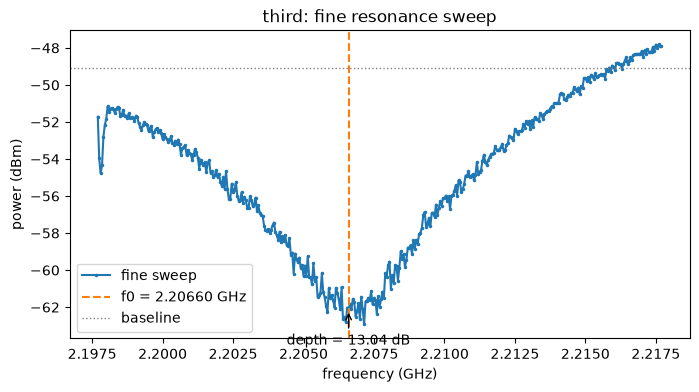

In [7]:
_ = analyze_resonance("third")

third: 500 segments
third: average value across all 500 segments: -0.01237 V (segment-to-segment std of that average: 0.00174 V)
third: average within-segment std: 0.01316 V (std of that std across segments: 0.00027 V)


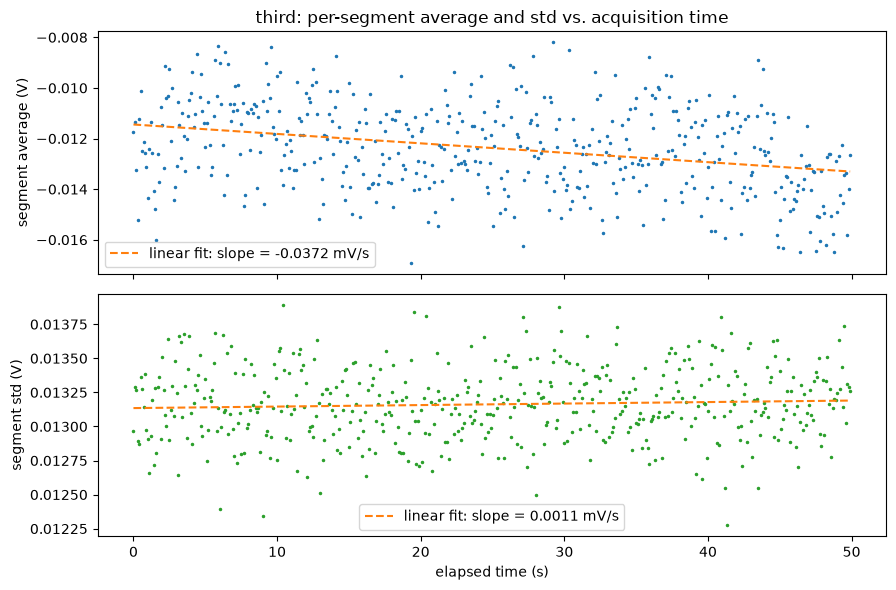

third: average trend: -0.0372 mV/s over 49.9 s (total change -1.8573 mV)
third: std trend: +0.0011 mV/s over 49.9 s (total change +0.0551 mV)


In [8]:
_ = analyze_waveform("third")

## `fourth_retake/`

Superseding the original `fourth/` run.

fourth_retake: f0 = 2.44700 GHz
fourth_retake: dip = -57.04 dBm, baseline = -49.84 dBm
fourth_retake: depth = 7.21 dB
fourth_retake: FWHM = 12.550 MHz, Q ~= 195


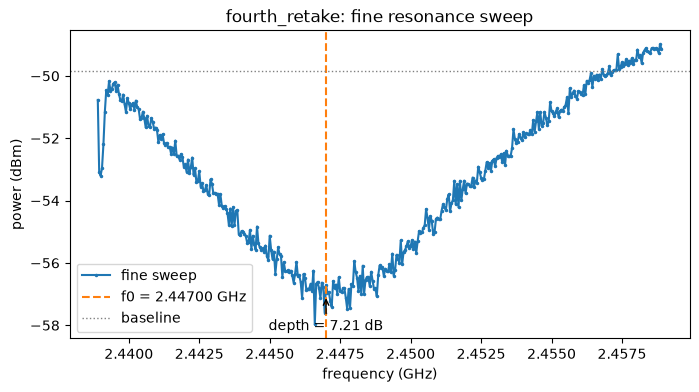

In [9]:
_ = analyze_resonance("fourth_retake")

fourth_retake: 500 segments
fourth_retake: average value across all 500 segments: -0.01298 V (segment-to-segment std of that average: 0.00177 V)
fourth_retake: average within-segment std: 0.01325 V (std of that std across segments: 0.00025 V)


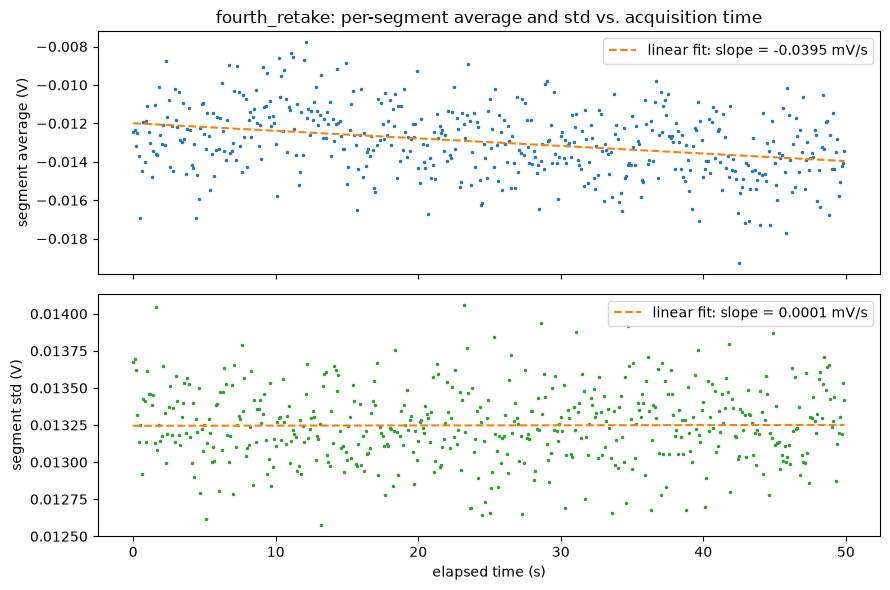

fourth_retake: average trend: -0.0395 mV/s over 49.9 s (total change -1.9686 mV)
fourth_retake: std trend: +0.0001 mV/s over 49.9 s (total change +0.0057 mV)


In [10]:
_ = analyze_waveform("fourth_retake")

## `fifth_retake/`

fifth_retake: f0 = 2.74100 GHz
fifth_retake: dip = -70.11 dBm, baseline = -46.71 dBm
fifth_retake: depth = 23.40 dB
fifth_retake: FWHM = 14.800 MHz, Q ~= 185


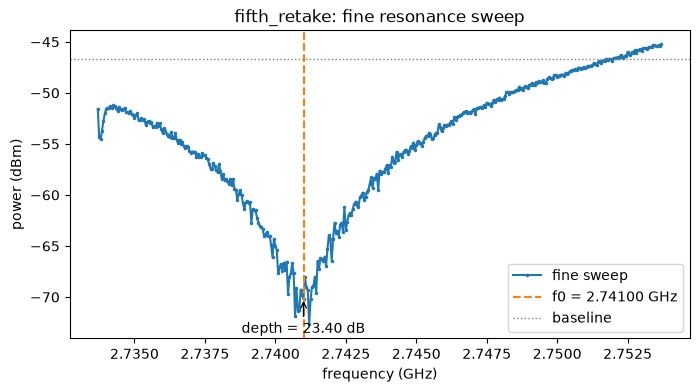

In [11]:
_ = analyze_resonance("fifth_retake")

fifth_retake: 500 segments
fifth_retake: average value across all 500 segments: -0.01421 V (segment-to-segment std of that average: 0.00189 V)
fifth_retake: average within-segment std: 0.01330 V (std of that std across segments: 0.00027 V)


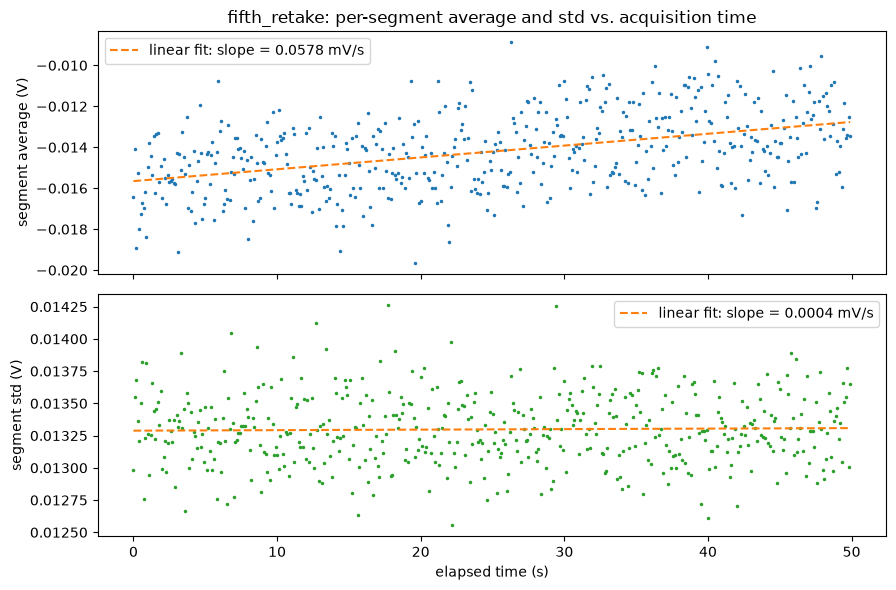

fifth_retake: average trend: +0.0578 mV/s over 49.9 s (total change +2.8829 mV)
fifth_retake: std trend: +0.0004 mV/s over 49.9 s (total change +0.0199 mV)


In [12]:
_ = analyze_waveform("fifth_retake")

## `sixth/`

sixth: f0 = 2.79605 GHz
sixth: dip = -59.59 dBm, baseline = -49.84 dBm
sixth: depth = 9.76 dB
sixth: FWHM = 11.450 MHz, Q ~= 244


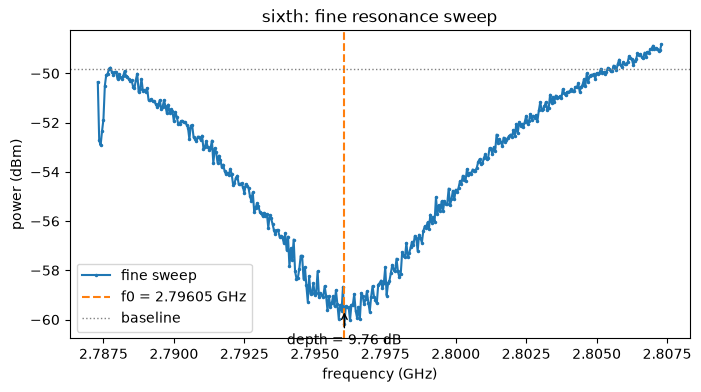

In [5]:
_ = analyze_resonance("sixth")

sixth: 500 segments
sixth: average value across all 500 segments: -0.01325 V (segment-to-segment std of that average: 0.00169 V)
sixth: average within-segment std: 0.01336 V (std of that std across segments: 0.00026 V)


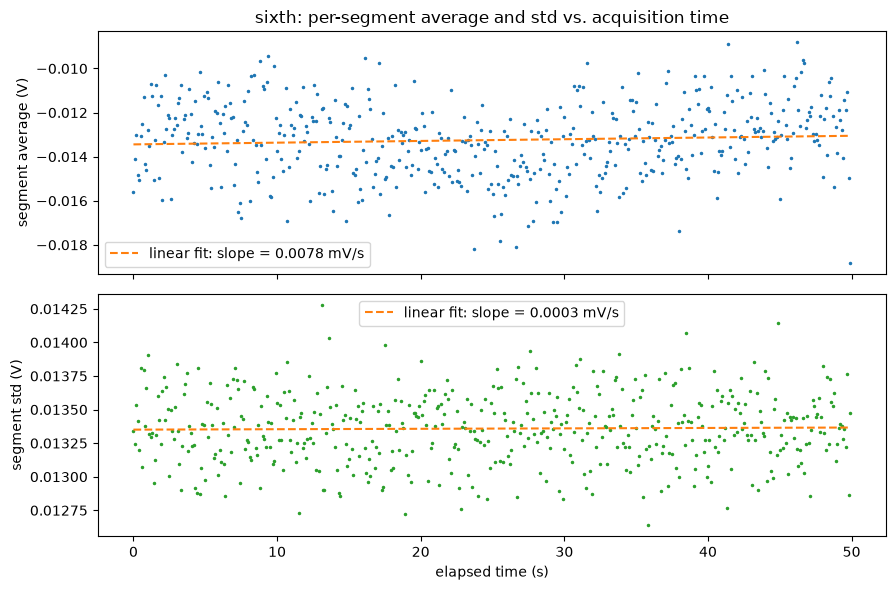

sixth: average trend: +0.0078 mV/s over 49.9 s (total change +0.3890 mV)
sixth: std trend: +0.0003 mV/s over 49.9 s (total change +0.0157 mV)


In [6]:
_ = analyze_waveform("sixth")

## `seventh/`

seventh: f0 = 2.82425 GHz
seventh: dip = -61.53 dBm, baseline = -49.16 dBm
seventh: depth = 12.37 dB
seventh: FWHM = 12.650 MHz, Q ~= 223


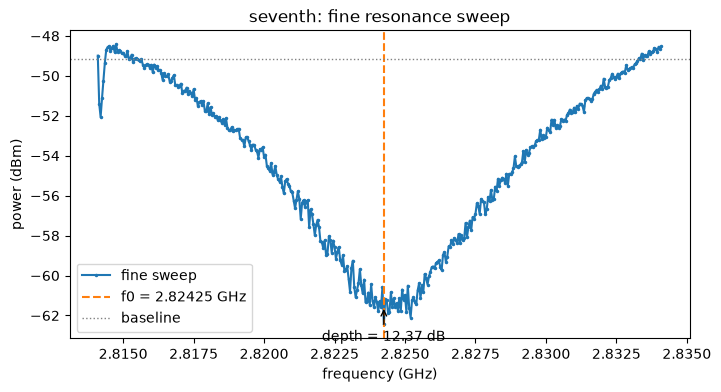

In [5]:
_ = analyze_resonance("seventh")

seventh: 500 segments
seventh: average value across all 500 segments: -0.01240 V (segment-to-segment std of that average: 0.00170 V)
seventh: average within-segment std: 0.01337 V (std of that std across segments: 0.00025 V)


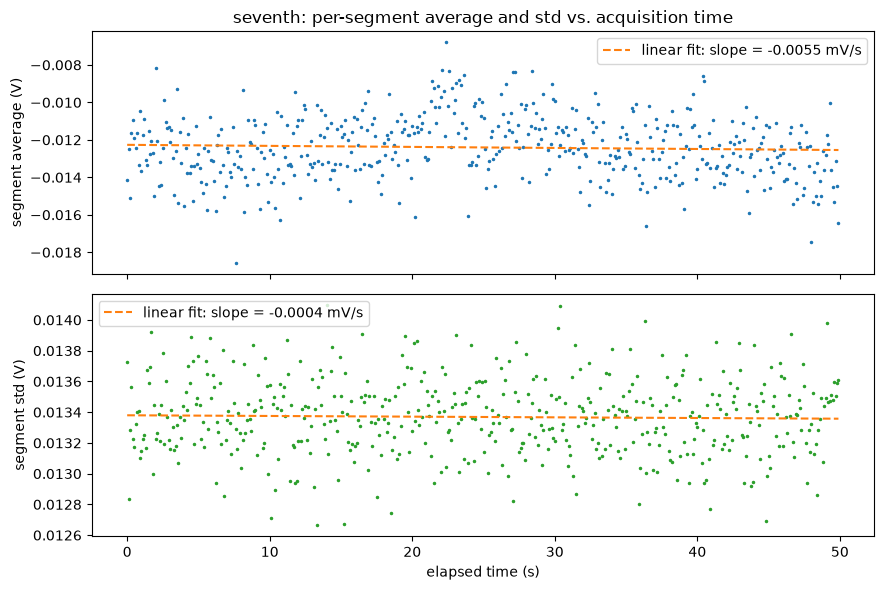

seventh: average trend: -0.0055 mV/s over 49.9 s (total change -0.2762 mV)
seventh: std trend: -0.0004 mV/s over 49.9 s (total change -0.0222 mV)


In [6]:
_ = analyze_waveform("seventh")

## `eighth/`

eighth: f0 = 2.43075 GHz
eighth: dip = -56.38 dBm, baseline = -44.83 dBm
eighth: depth = 11.55 dB
eighth: FWHM = 14.950 MHz, Q ~= 163


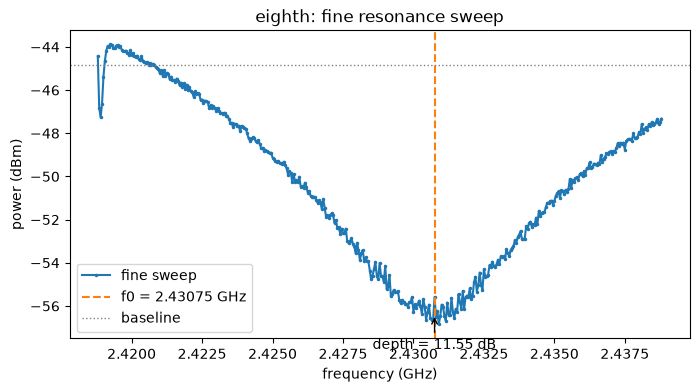

In [5]:
_ = analyze_resonance("eighth")

eighth: 500 segments
eighth: average value across all 500 segments: -0.01246 V (segment-to-segment std of that average: 0.00162 V)
eighth: average within-segment std: 0.01338 V (std of that std across segments: 0.00027 V)


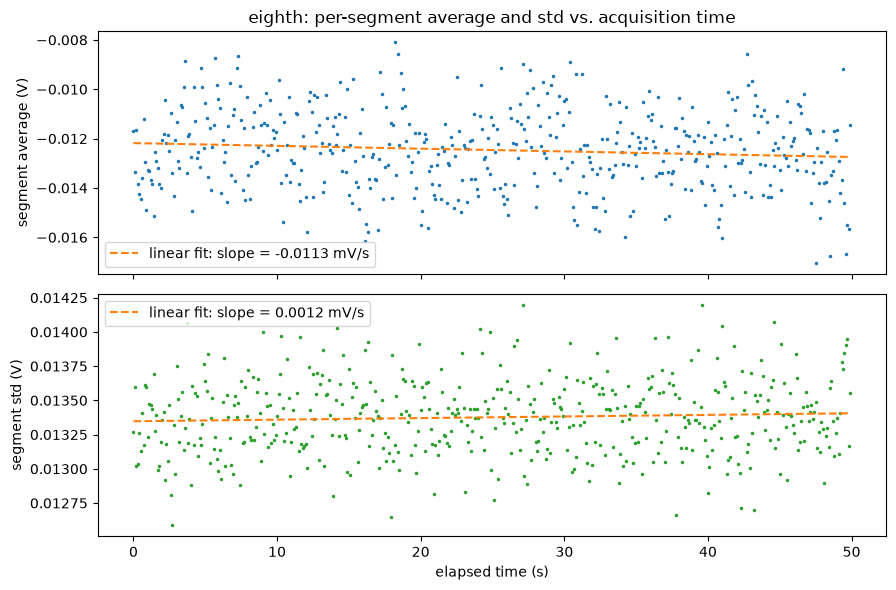

eighth: average trend: -0.0113 mV/s over 49.9 s (total change -0.5615 mV)
eighth: std trend: +0.0012 mV/s over 49.9 s (total change +0.0581 mV)


In [6]:
_ = analyze_waveform("eighth")

## `ninth/`

ninth: f0 = 2.87435 GHz
ninth: dip = -51.66 dBm, baseline = -48.68 dBm
ninth: depth = 2.99 dB
ninth: FWHM = 14.050 MHz, Q ~= 205


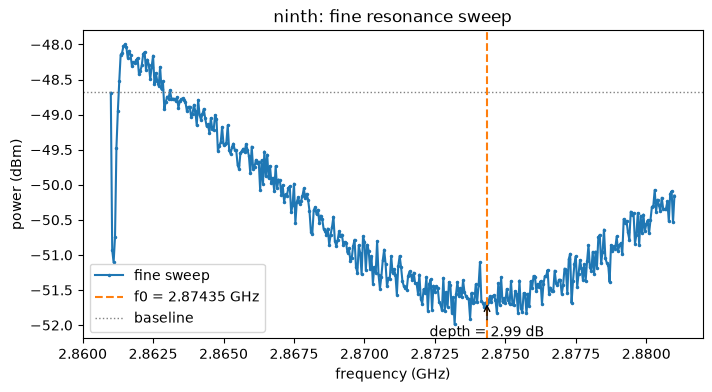

In [5]:
_ = analyze_resonance("ninth")

ninth: 500 segments
ninth: average value across all 500 segments: -0.01447 V (segment-to-segment std of that average: 0.00177 V)
ninth: average within-segment std: 0.01348 V (std of that std across segments: 0.00027 V)


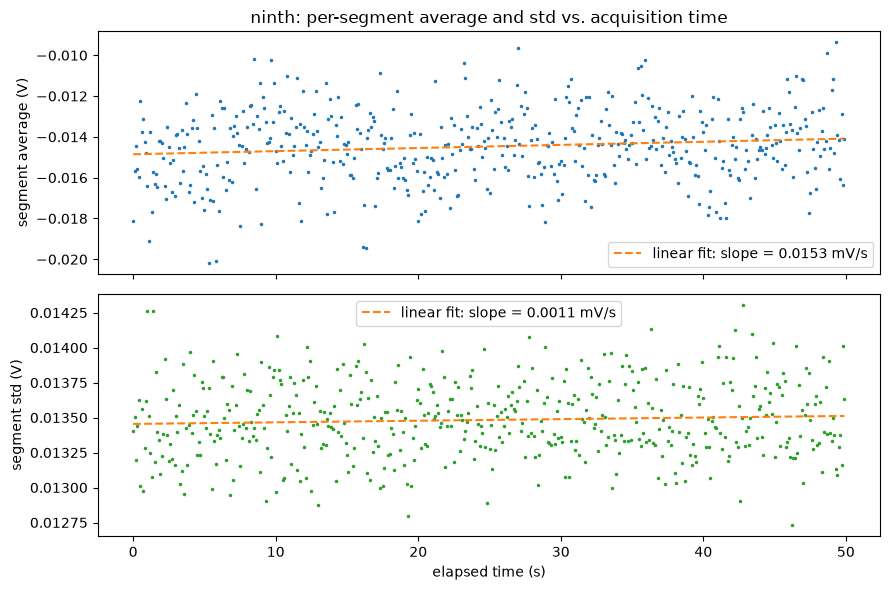

ninth: average trend: +0.0153 mV/s over 49.9 s (total change +0.7648 mV)
ninth: std trend: +0.0011 mV/s over 49.9 s (total change +0.0570 mV)


In [6]:
_ = analyze_waveform("ninth")

## `tenth/`

tenth: f0 = 2.71985 GHz
tenth: dip = -77.06 dBm, baseline = -50.20 dBm
tenth: depth = 26.86 dB
tenth: FWHM = 14.000 MHz, Q ~= 194


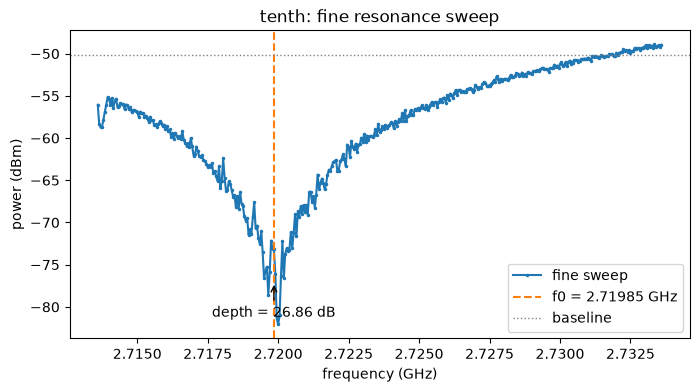

In [5]:
_ = analyze_resonance("tenth")

tenth: 500 segments
tenth: average value across all 500 segments: -0.01380 V (segment-to-segment std of that average: 0.00182 V)
tenth: average within-segment std: 0.01339 V (std of that std across segments: 0.00028 V)


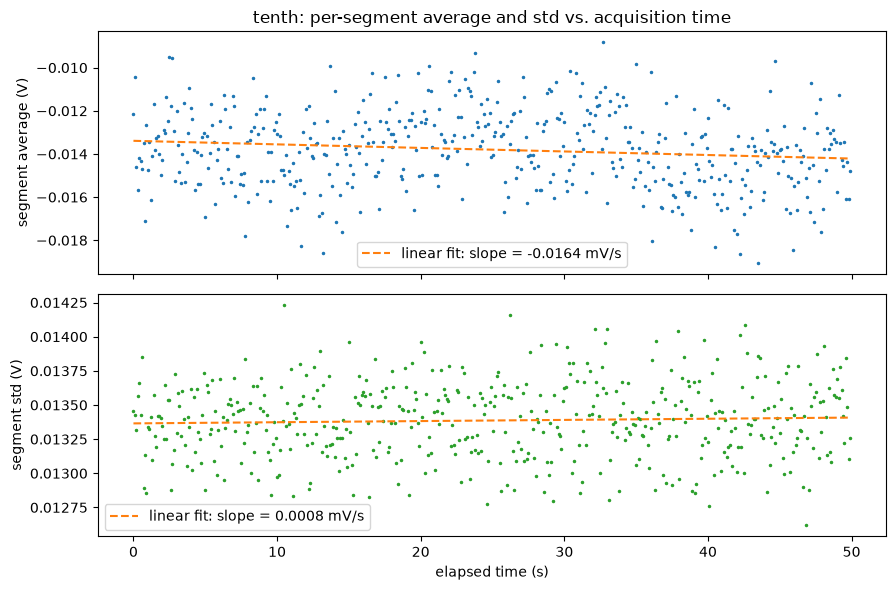

tenth: average trend: -0.0164 mV/s over 49.9 s (total change -0.8205 mV)
tenth: std trend: +0.0008 mV/s over 49.9 s (total change +0.0424 mV)


In [6]:
_ = analyze_waveform("tenth")

## `tenth_add/`

tenth_add: f0 = 2.72815 GHz
tenth_add: dip = -61.83 dBm, baseline = -50.09 dBm
tenth_add: depth = 11.73 dB
tenth_add: FWHM = 14.050 MHz, Q ~= 194


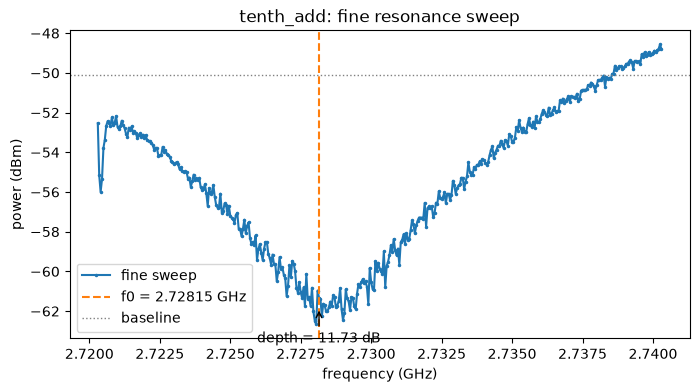

In [7]:
_ = analyze_resonance("tenth_add")

tenth_add: 500 segments
tenth_add: average value across all 500 segments: -0.01400 V (segment-to-segment std of that average: 0.00161 V)
tenth_add: average within-segment std: 0.01342 V (std of that std across segments: 0.00026 V)


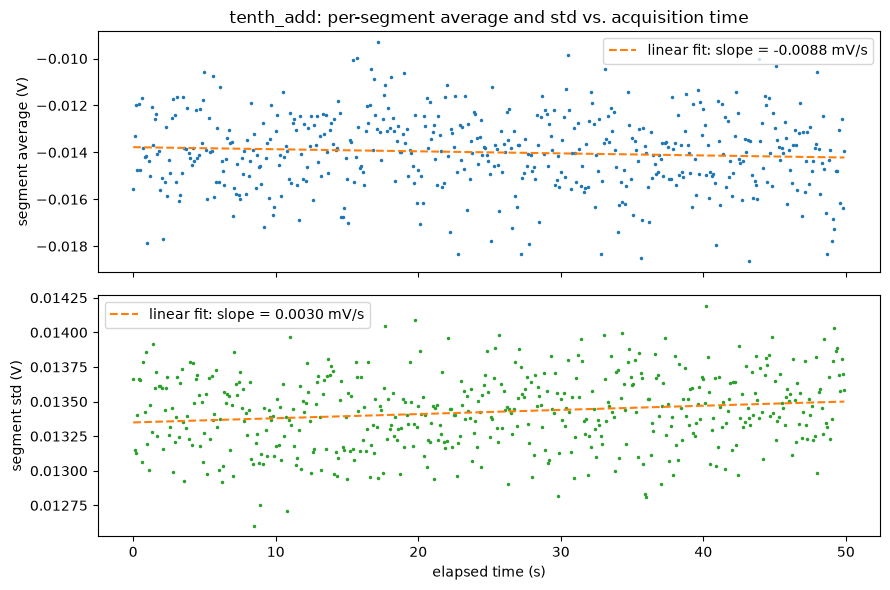

tenth_add: average trend: -0.0088 mV/s over 49.9 s (total change -0.4397 mV)
tenth_add: std trend: +0.0030 mV/s over 49.9 s (total change +0.1506 mV)


In [8]:
_ = analyze_waveform("tenth_add")

## `eleventh/`

eleventh: f0 = 2.29695 GHz
eleventh: dip = -57.93 dBm, baseline = -47.28 dBm
eleventh: depth = 10.65 dB
eleventh: FWHM = 11.300 MHz, Q ~= 203


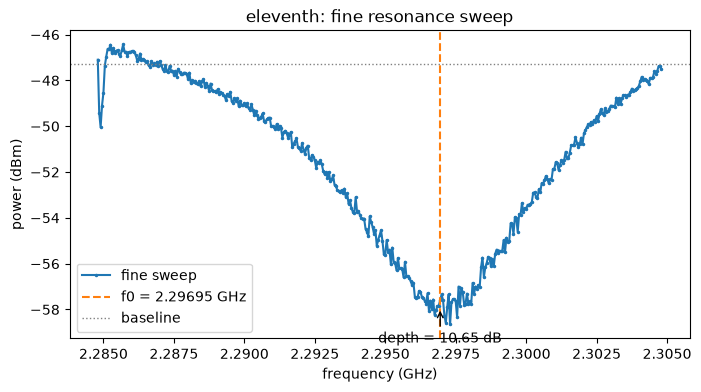

In [5]:
_ = analyze_resonance("eleventh")

eleventh: 1000 segments
eleventh: average value across all 1000 segments: -0.01288 V (segment-to-segment std of that average: 0.00169 V)
eleventh: average within-segment std: 0.01345 V (std of that std across segments: 0.00027 V)


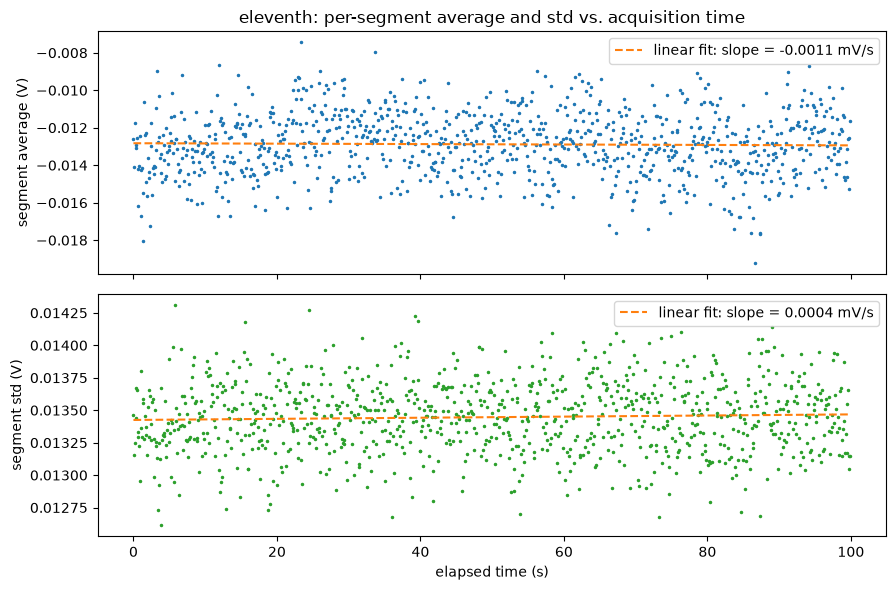

eleventh: average trend: -0.0011 mV/s over 99.9 s (total change -0.1132 mV)
eleventh: std trend: +0.0004 mV/s over 99.9 s (total change +0.0428 mV)


In [6]:
_ = analyze_waveform("eleventh")

## `twelfth/`

twelfth: f0 = 2.91630 GHz
twelfth: dip = -68.80 dBm, baseline = -49.06 dBm
twelfth: depth = 19.74 dB
twelfth: FWHM = 13.850 MHz, Q ~= 211


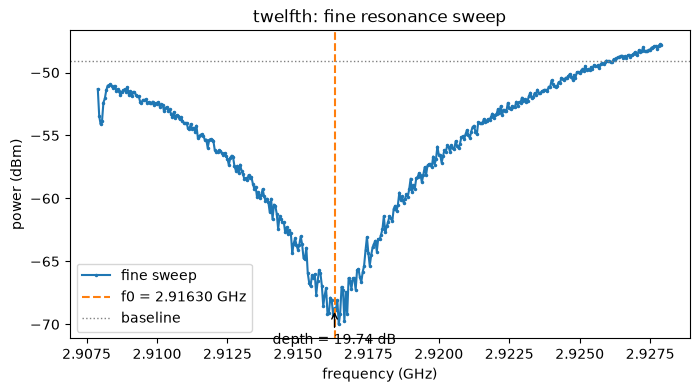

In [5]:
_ = analyze_resonance("twelfth")

twelfth: 1000 segments
twelfth: average value across all 1000 segments: -0.01536 V (segment-to-segment std of that average: 0.00166 V)
twelfth: average within-segment std: 0.01346 V (std of that std across segments: 0.00027 V)


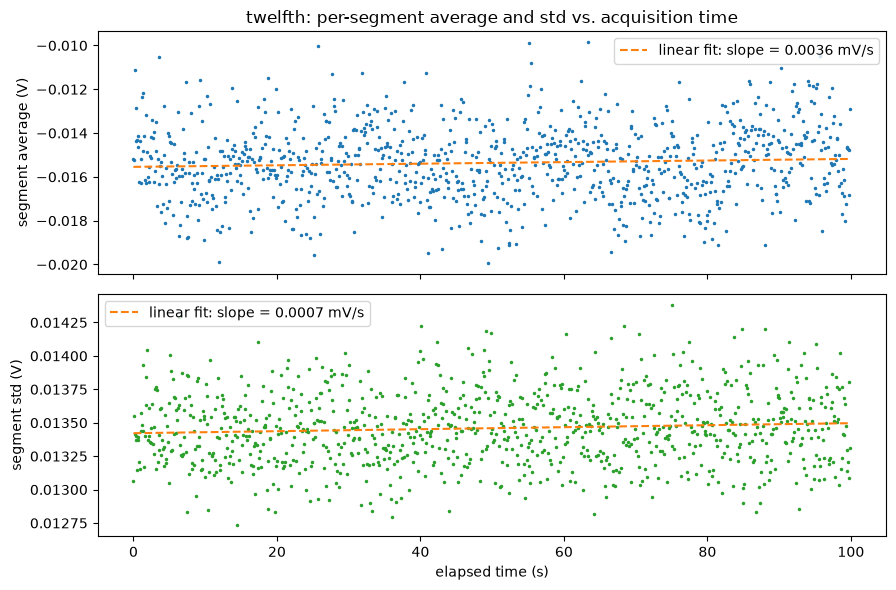

twelfth: average trend: +0.0036 mV/s over 99.9 s (total change +0.3624 mV)
twelfth: std trend: +0.0007 mV/s over 99.9 s (total change +0.0748 mV)


In [6]:
_ = analyze_waveform("twelfth")

## `thirteenth/`

thirteenth: f0 = 2.54495 GHz
thirteenth: dip = -60.78 dBm, baseline = -51.11 dBm
thirteenth: depth = 9.67 dB
thirteenth: FWHM = 14.250 MHz, Q ~= 179


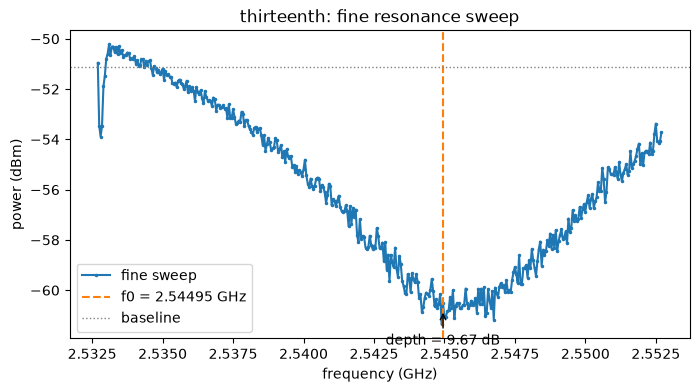

In [5]:
_ = analyze_resonance("thirteenth")

thirteenth: 500 segments
thirteenth: average value across all 500 segments: -0.01474 V (segment-to-segment std of that average: 0.00168 V)
thirteenth: average within-segment std: 0.01348 V (std of that std across segments: 0.00027 V)


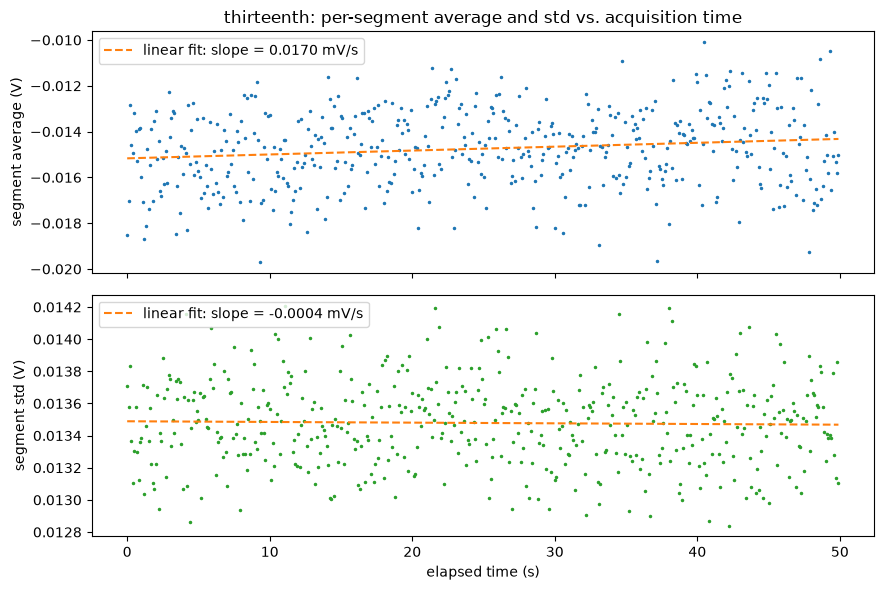

thirteenth: average trend: +0.0170 mV/s over 49.9 s (total change +0.8466 mV)
thirteenth: std trend: -0.0004 mV/s over 49.9 s (total change -0.0212 mV)


In [6]:
_ = analyze_waveform("thirteenth")

## `fourteenth/`

fourteenth: f0 = 2.97070 GHz
fourteenth: dip = -60.98 dBm, baseline = -51.22 dBm
fourteenth: depth = 9.76 dB
fourteenth: FWHM = 11.500 MHz, Q ~= 258


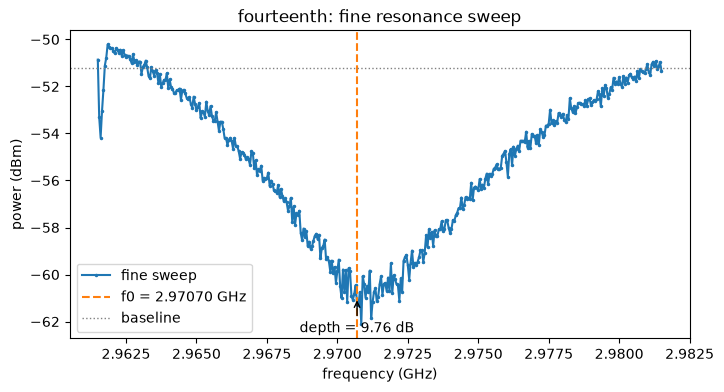

In [5]:
_ = analyze_resonance("fourteenth")

fourteenth: 500 segments
fourteenth: average value across all 500 segments: -0.01381 V (segment-to-segment std of that average: 0.00166 V)
fourteenth: average within-segment std: 0.01352 V (std of that std across segments: 0.00028 V)


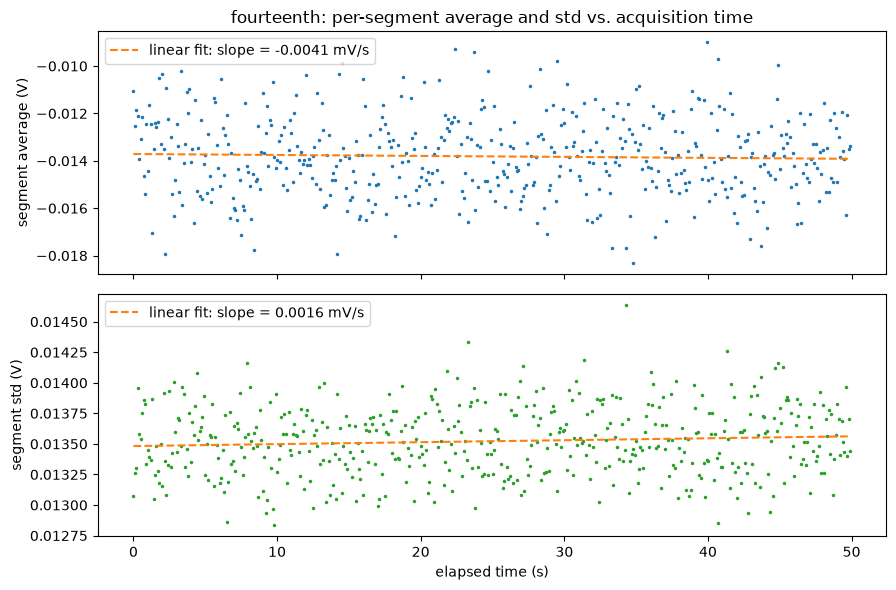

fourteenth: average trend: -0.0041 mV/s over 49.9 s (total change -0.2030 mV)
fourteenth: std trend: +0.0016 mV/s over 49.9 s (total change +0.0794 mV)


In [6]:
_ = analyze_waveform("fourteenth")

## `fifteenth/`

fifteenth: f0 = 2.83495 GHz
fifteenth: dip = -64.60 dBm, baseline = -46.19 dBm
fifteenth: depth = 18.41 dB
fifteenth: FWHM = 15.200 MHz, Q ~= 187


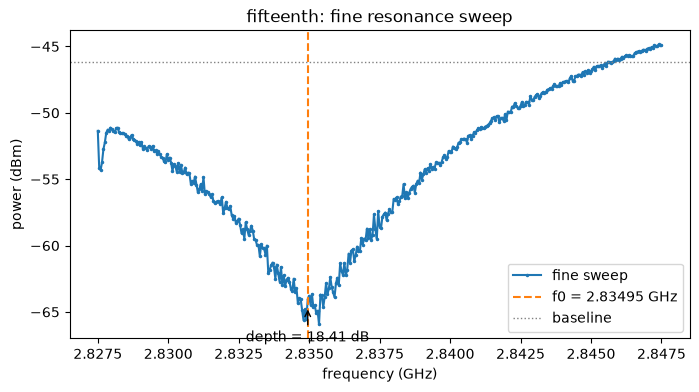

In [7]:
_ = analyze_resonance("fifteenth")

fifteenth: 500 segments
fifteenth: average value across all 500 segments: -0.01374 V (segment-to-segment std of that average: 0.00173 V)
fifteenth: average within-segment std: 0.01349 V (std of that std across segments: 0.00027 V)


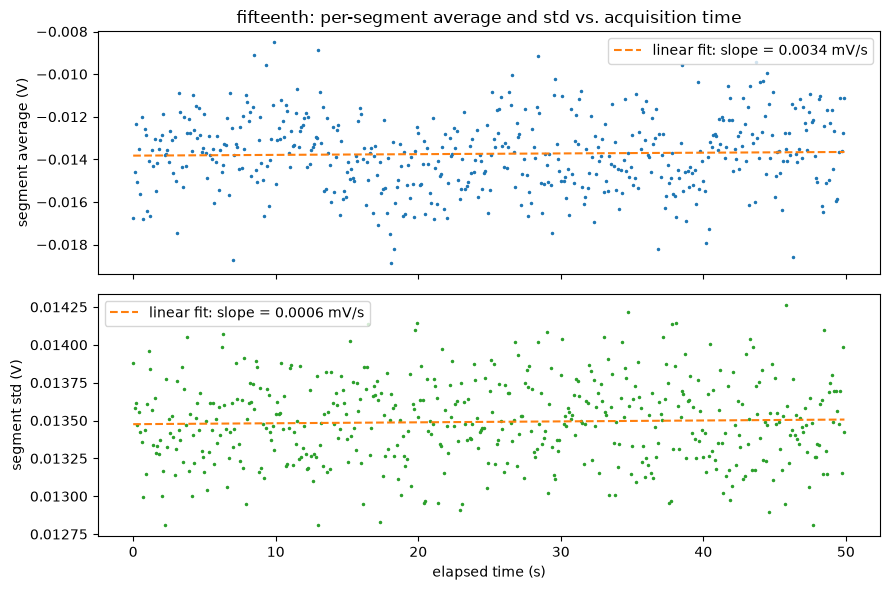

fifteenth: average trend: +0.0034 mV/s over 49.9 s (total change +0.1712 mV)
fifteenth: std trend: +0.0006 mV/s over 49.9 s (total change +0.0304 mV)


In [8]:
_ = analyze_waveform("fifteenth")

## All runs: resonance frequency vs. average signal voltage

Plots each run's resonance frequency (`f0`, from its fine sweep) against its average
signal voltage (mean of the per-segment average across all captured segments) -- one
point per run. Uses the retakes (`fourth_retake`, `fifth_retake`) in place of the
original `fourth`/`fifth` runs rather than `find_run_names()`'s full auto-discovery, so
superseded runs don't also show up alongside their retakes.

second: f0 = 2.67525 GHz, average voltage = -0.01422 +/- 0.00178 V
third: f0 = 2.20660 GHz, average voltage = -0.01237 +/- 0.00174 V
fourth_retake: f0 = 2.44700 GHz, average voltage = -0.01298 +/- 0.00177 V
fifth_retake: f0 = 2.74100 GHz, average voltage = -0.01421 +/- 0.00189 V


sixth: f0 = 2.79605 GHz, average voltage = -0.01325 +/- 0.00169 V


seventh: f0 = 2.82425 GHz, average voltage = -0.01240 +/- 0.00170 V
eighth: f0 = 2.43075 GHz, average voltage = -0.01246 +/- 0.00162 V
ninth: f0 = 2.87435 GHz, average voltage = -0.01447 +/- 0.00177 V
tenth: f0 = 2.71985 GHz, average voltage = -0.01380 +/- 0.00182 V
tenth_add: f0 = 2.72815 GHz, average voltage = -0.01400 +/- 0.00161 V


eleventh: f0 = 2.29695 GHz, average voltage = -0.01288 +/- 0.00169 V


twelfth: f0 = 2.91630 GHz, average voltage = -0.01536 +/- 0.00166 V
thirteenth: f0 = 2.54495 GHz, average voltage = -0.01474 +/- 0.00168 V
fourteenth: f0 = 2.97070 GHz, average voltage = -0.01381 +/- 0.00166 V
fifteenth: f0 = 2.83495 GHz, average voltage = -0.01374 +/- 0.00173 V


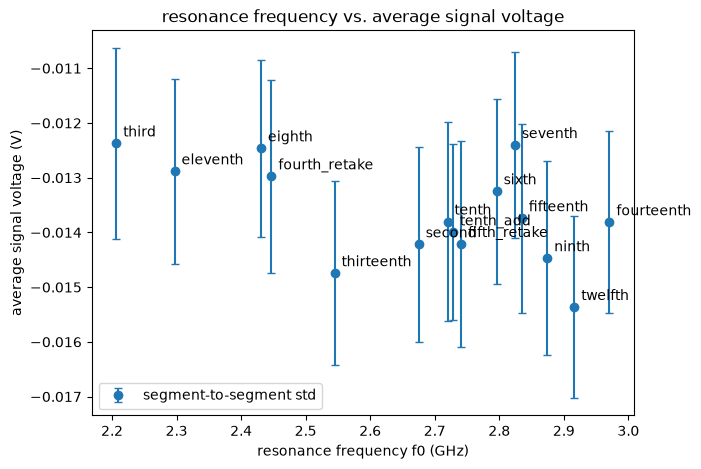

In [9]:
def plot_resonance_vs_voltage(run_names=None):
    if run_names is None:
        run_names = find_run_names()

    f0s_ghz = []
    avg_voltages = []
    voltage_errs = []
    for run_name in run_names:
        result = _fine_sweep_result(run_name)
        seg_mean, _seg_std, _elapsed_s = _waveform_stats(run_name)
        f0s_ghz.append(result["f0_hz"] / 1e9)
        avg_voltages.append(seg_mean.mean())
        voltage_errs.append(seg_mean.std())
        print(f"{run_name}: f0 = {result['f0_hz']/1e9:.5f} GHz, "
              f"average voltage = {seg_mean.mean():.5f} +/- {seg_mean.std():.5f} V")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(f0s_ghz, avg_voltages, yerr=voltage_errs, fmt="o", capsize=3,
                label="segment-to-segment std")
    for name, x, y in zip(run_names, f0s_ghz, avg_voltages):
        ax.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
    ax.set_xlabel("resonance frequency f0 (GHz)")
    ax.set_ylabel("average signal voltage (V)")
    ax.set_title("resonance frequency vs. average signal voltage")
    ax.legend()
    plt.show()

    return list(zip(run_names, f0s_ghz, avg_voltages, voltage_errs))


_ = plot_resonance_vs_voltage(["second", "third", "fourth_retake", "fifth_retake", "sixth", "seventh", "eighth", "ninth", "tenth", "tenth_add", "eleventh", "twelfth", "thirteenth", "fourteenth", "fifteenth"])

## Voltage normalized by dip depth

Same runs as above, but dividing each run's average signal voltage by its dip depth
(in dB) to see whether that removes some of the scatter in the raw f0-vs-voltage plot
-- e.g. if the average voltage partly tracks how strongly the resonator is coupled
(reflected in the depth) rather than f0 itself.

second: f0 = 2.67525 GHz, depth = 14.24 dB, average voltage = -0.01422 V, voltage/depth = -0.000999 +/- 0.000125 V/dB
third: f0 = 2.20660 GHz, depth = 13.04 dB, average voltage = -0.01237 V, voltage/depth = -0.000949 +/- 0.000134 V/dB
fourth_retake: f0 = 2.44700 GHz, depth = 7.21 dB, average voltage = -0.01298 V, voltage/depth = -0.001801 +/- 0.000245 V/dB
fifth_retake: f0 = 2.74100 GHz, depth = 23.40 dB, average voltage = -0.01421 V, voltage/depth = -0.000607 +/- 0.000081 V/dB
sixth: f0 = 2.79605 GHz, depth = 9.76 dB, average voltage = -0.01325 V, voltage/depth = -0.001357 +/- 0.000173 V/dB
seventh: f0 = 2.82425 GHz, depth = 12.37 dB, average voltage = -0.01240 V, voltage/depth = -0.001002 +/- 0.000137 V/dB
eighth: f0 = 2.43075 GHz, depth = 11.55 dB, average voltage = -0.01246 V, voltage/depth = -0.001079 +/- 0.000140 V/dB


ninth: f0 = 2.87435 GHz, depth = 2.99 dB, average voltage = -0.01447 V, voltage/depth = -0.004844 +/- 0.000594 V/dB
tenth: f0 = 2.71985 GHz, depth = 26.86 dB, average voltage = -0.01380 V, voltage/depth = -0.000514 +/- 0.000068 V/dB
tenth_add: f0 = 2.72815 GHz, depth = 11.73 dB, average voltage = -0.01400 V, voltage/depth = -0.001193 +/- 0.000137 V/dB
eleventh: f0 = 2.29695 GHz, depth = 10.65 dB, average voltage = -0.01288 V, voltage/depth = -0.001210 +/- 0.000159 V/dB
twelfth: f0 = 2.91630 GHz, depth = 19.74 dB, average voltage = -0.01536 V, voltage/depth = -0.000778 +/- 0.000084 V/dB


thirteenth: f0 = 2.54495 GHz, depth = 9.67 dB, average voltage = -0.01474 V, voltage/depth = -0.001525 +/- 0.000174 V/dB
fourteenth: f0 = 2.97070 GHz, depth = 9.76 dB, average voltage = -0.01381 V, voltage/depth = -0.001416 +/- 0.000171 V/dB
fifteenth: f0 = 2.83495 GHz, depth = 18.41 dB, average voltage = -0.01374 V, voltage/depth = -0.000746 +/- 0.000094 V/dB


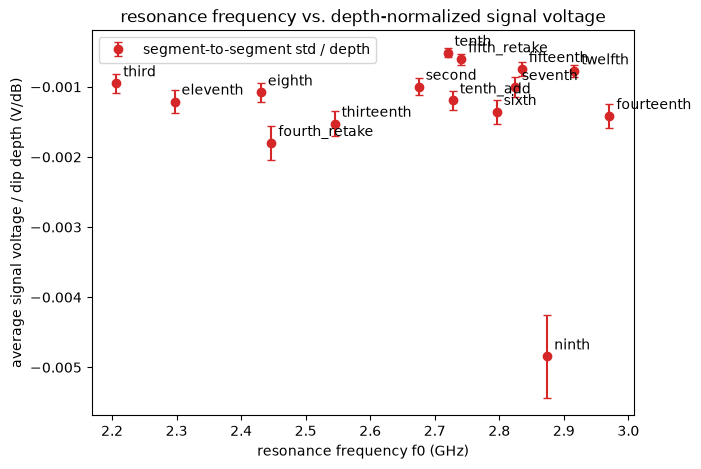

In [10]:
def plot_resonance_vs_normalized_voltage(run_names=None):
    if run_names is None:
        run_names = find_run_names()

    f0s_ghz = []
    normalized = []
    normalized_errs = []
    for run_name in run_names:
        result = _fine_sweep_result(run_name)
        depth_db = result["baseline_dbm"] - result["dip_dbm"]
        seg_mean, _seg_std, _elapsed_s = _waveform_stats(run_name)
        avg_voltage = seg_mean.mean()
        ratio = avg_voltage / depth_db
        # Depth has no associated uncertainty here, so the ratio's error
        # bar is just the voltage's std/depth_db (simple scaling, not a
        # full error propagation).
        ratio_err = seg_mean.std() / depth_db
        f0s_ghz.append(result["f0_hz"] / 1e9)
        normalized.append(ratio)
        normalized_errs.append(ratio_err)
        print(f"{run_name}: f0 = {result['f0_hz']/1e9:.5f} GHz, depth = {depth_db:.2f} dB, "
              f"average voltage = {avg_voltage:.5f} V, voltage/depth = {ratio:.6f} +/- {ratio_err:.6f} V/dB")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(f0s_ghz, normalized, yerr=normalized_errs, fmt="o", color="C3", capsize=3,
                label="segment-to-segment std / depth")
    for name, x, y in zip(run_names, f0s_ghz, normalized):
        ax.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
    ax.set_xlabel("resonance frequency f0 (GHz)")
    ax.set_ylabel("average signal voltage / dip depth (V/dB)")
    ax.set_title("resonance frequency vs. depth-normalized signal voltage")
    ax.legend()
    plt.show()

    return list(zip(run_names, f0s_ghz, normalized, normalized_errs))


_ = plot_resonance_vs_normalized_voltage(
    ["second", "third", "fourth_retake", "fifth_retake", "sixth", "seventh", "eighth", "ninth", "tenth", "tenth_add", "eleventh", "twelfth", "thirteenth", "fourteenth", "fifteenth"]
)

## Background-subtracted voltage

Same runs as the surveys above, but subtracting each run's saved background
(`<run>_bg.npy`, RF off) average voltage from its signal average voltage first --
removes any RF-independent DC offset (e.g. scope/AWG baseline) common to both, so what's
left should be closer to the resonance-driven signal itself. Error bars combine the
segment-to-segment std of the signal and background acquisitions in quadrature.

second: f0 = 2.67525 GHz, signal = -0.01422 V, background = -0.01195 V, signal - background = -0.00227 +/- 0.00238 V
third: f0 = 2.20660 GHz, signal = -0.01237 V, background = -0.01184 V, signal - background = -0.00053 +/- 0.00238 V
fourth_retake: f0 = 2.44700 GHz, signal = -0.01298 V, background = -0.01421 V, signal - background = +0.00123 +/- 0.00239 V
fifth_retake: f0 = 2.74100 GHz, signal = -0.01421 V, background = -0.01236 V, signal - background = -0.00185 +/- 0.00251 V


sixth: f0 = 2.79605 GHz, signal = -0.01325 V, background = -0.01206 V, signal - background = -0.00119 +/- 0.00231 V
seventh: f0 = 2.82425 GHz, signal = -0.01240 V, background = -0.01329 V, signal - background = +0.00089 +/- 0.00242 V
eighth: f0 = 2.43075 GHz, signal = -0.01246 V, background = -0.01348 V, signal - background = +0.00102 +/- 0.00231 V


ninth: f0 = 2.87435 GHz, signal = -0.01447 V, background = -0.01330 V, signal - background = -0.00117 +/- 0.00244 V
tenth: f0 = 2.71985 GHz, signal = -0.01380 V, background = -0.01253 V, signal - background = -0.00127 +/- 0.00243 V
tenth_add: f0 = 2.72815 GHz, signal = -0.01400 V, background = -0.01469 V, signal - background = +0.00069 +/- 0.00238 V


eleventh: f0 = 2.29695 GHz, signal = -0.01288 V, background = -0.01622 V, signal - background = +0.00333 +/- 0.00240 V
twelfth: f0 = 2.91630 GHz, signal = -0.01536 V, background = -0.01533 V, signal - background = -0.00003 +/- 0.00230 V
thirteenth: f0 = 2.54495 GHz, signal = -0.01474 V, background = -0.01332 V, signal - background = -0.00143 +/- 0.00238 V


fourteenth: f0 = 2.97070 GHz, signal = -0.01381 V, background = -0.01501 V, signal - background = +0.00119 +/- 0.00245 V
fifteenth: f0 = 2.83495 GHz, signal = -0.01374 V, background = -0.01304 V, signal - background = -0.00070 +/- 0.00245 V


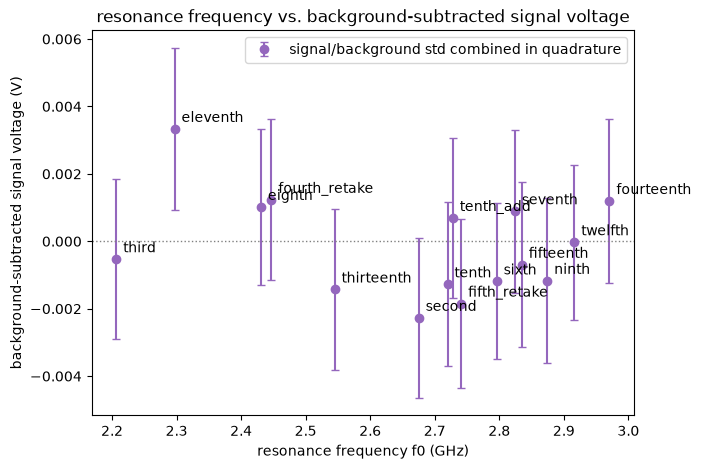

In [11]:
def plot_resonance_vs_bg_subtracted_voltage(run_names=None):
    if run_names is None:
        run_names = [n for n in find_run_names() if _bg_waveform_stats(n) is not None]

    f0s_ghz = []
    net_voltages = []
    net_errs = []
    for run_name in run_names:
        bg_stats = _bg_waveform_stats(run_name)
        if bg_stats is None:
            print(f"{run_name}: no background acquisition saved -- skipping")
            continue
        bg_seg_mean, _bg_seg_std = bg_stats
        result = _fine_sweep_result(run_name)
        seg_mean, _seg_std, _elapsed_s = _waveform_stats(run_name)

        net_voltage = seg_mean.mean() - bg_seg_mean.mean()
        net_err = float(np.sqrt(seg_mean.std() ** 2 + bg_seg_mean.std() ** 2))

        f0s_ghz.append(result["f0_hz"] / 1e9)
        net_voltages.append(net_voltage)
        net_errs.append(net_err)
        print(f"{run_name}: f0 = {result['f0_hz']/1e9:.5f} GHz, "
              f"signal = {seg_mean.mean():.5f} V, background = {bg_seg_mean.mean():.5f} V, "
              f"signal - background = {net_voltage:+.5f} +/- {net_err:.5f} V")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(f0s_ghz, net_voltages, yerr=net_errs, fmt="o", color="C4", capsize=3,
                label="signal/background std combined in quadrature")
    for name, x, y in zip(run_names, f0s_ghz, net_voltages):
        ax.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel("resonance frequency f0 (GHz)")
    ax.set_ylabel("background-subtracted signal voltage (V)")
    ax.set_title("resonance frequency vs. background-subtracted signal voltage")
    ax.legend()
    plt.show()

    return list(zip(run_names, f0s_ghz, net_voltages, net_errs))


_ = plot_resonance_vs_bg_subtracted_voltage(
    ["second", "third", "fourth_retake", "fifth_retake", "sixth", "seventh", "eighth", "ninth", "tenth", "tenth_add", "eleventh", "twelfth", "thirteenth", "fourteenth", "fifteenth"]
)

## Background-subtracted voltage (SEM error bars)

Same as the background-subtracted plot above, but with error bars showing the
**standard error of the mean** (SEM = segment-to-segment std / sqrt(N segments)) instead
of the raw std. Raw std measures how much the signal itself fluctuates segment to
segment and doesn't shrink with more segments; SEM measures how precisely we know the
*average*, and does shrink as sqrt(N) -- the more appropriate error bar for judging
whether a nonzero background-subtracted value is statistically meaningful. Runs with
1000 segments (e.g. `eleventh`) get a smaller SEM than the 500-segment runs even though
their raw std is similar.

second: f0 = 2.67525 GHz, signal - background = -0.00227 +/- 0.000106 V (SEM) [21.4 sigma]
third: f0 = 2.20660 GHz, signal - background = -0.00053 +/- 0.000106 V (SEM) [5.0 sigma]


fourth_retake: f0 = 2.44700 GHz, signal - background = +0.00123 +/- 0.000107 V (SEM) [11.5 sigma]
fifth_retake: f0 = 2.74100 GHz, signal - background = -0.00185 +/- 0.000112 V (SEM) [16.5 sigma]
sixth: f0 = 2.79605 GHz, signal - background = -0.00119 +/- 0.000103 V (SEM) [11.5 sigma]
seventh: f0 = 2.82425 GHz, signal - background = +0.00089 +/- 0.000108 V (SEM) [8.2 sigma]


eighth: f0 = 2.43075 GHz, signal - background = +0.00102 +/- 0.000103 V (SEM) [9.9 sigma]
ninth: f0 = 2.87435 GHz, signal - background = -0.00117 +/- 0.000109 V (SEM) [10.7 sigma]
tenth: f0 = 2.71985 GHz, signal - background = -0.00127 +/- 0.000109 V (SEM) [11.8 sigma]


tenth_add: f0 = 2.72815 GHz, signal - background = +0.00069 +/- 0.000106 V (SEM) [6.5 sigma]
eleventh: f0 = 2.29695 GHz, signal - background = +0.00333 +/- 0.000120 V (SEM) [27.7 sigma]
twelfth: f0 = 2.91630 GHz, signal - background = -0.00003 +/- 0.000114 V (SEM) [0.2 sigma]


thirteenth: f0 = 2.54495 GHz, signal - background = -0.00143 +/- 0.000131 V (SEM) [10.9 sigma]
fourteenth: f0 = 2.97070 GHz, signal - background = +0.00119 +/- 0.000136 V (SEM) [8.8 sigma]


fifteenth: f0 = 2.83495 GHz, signal - background = -0.00070 +/- 0.000134 V (SEM) [5.2 sigma]


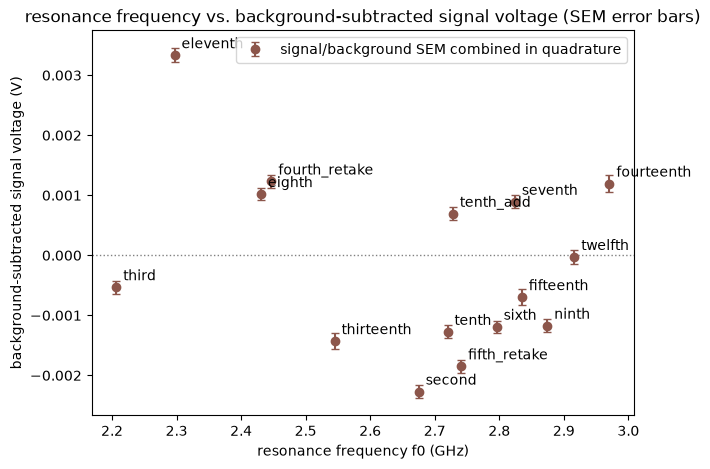

In [12]:
def plot_resonance_vs_bg_subtracted_voltage_sem(run_names=None):
    if run_names is None:
        run_names = [n for n in find_run_names() if _bg_waveform_stats(n) is not None]

    f0s_ghz = []
    net_voltages = []
    net_sems = []
    for run_name in run_names:
        bg_stats = _bg_waveform_stats(run_name)
        if bg_stats is None:
            print(f"{run_name}: no background acquisition saved -- skipping")
            continue
        bg_seg_mean, _bg_seg_std = bg_stats
        result = _fine_sweep_result(run_name)
        seg_mean, _seg_std, _elapsed_s = _waveform_stats(run_name)

        net_voltage = seg_mean.mean() - bg_seg_mean.mean()
        sig_sem = seg_mean.std() / np.sqrt(len(seg_mean))
        bg_sem = bg_seg_mean.std() / np.sqrt(len(bg_seg_mean))
        net_sem = float(np.sqrt(sig_sem ** 2 + bg_sem ** 2))

        f0s_ghz.append(result["f0_hz"] / 1e9)
        net_voltages.append(net_voltage)
        net_sems.append(net_sem)
        n_sigma = abs(net_voltage) / net_sem if net_sem > 0 else float("inf")
        print(f"{run_name}: f0 = {result['f0_hz']/1e9:.5f} GHz, "
              f"signal - background = {net_voltage:+.5f} +/- {net_sem:.6f} V (SEM) "
              f"[{n_sigma:.1f} sigma]")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(f0s_ghz, net_voltages, yerr=net_sems, fmt="o", color="C5", capsize=3,
                label="signal/background SEM combined in quadrature")
    for name, x, y in zip(run_names, f0s_ghz, net_voltages):
        ax.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel("resonance frequency f0 (GHz)")
    ax.set_ylabel("background-subtracted signal voltage (V)")
    ax.set_title("resonance frequency vs. background-subtracted signal voltage (SEM error bars)")
    ax.legend()
    plt.show()

    return list(zip(run_names, f0s_ghz, net_voltages, net_sems))


_ = plot_resonance_vs_bg_subtracted_voltage_sem(
    ["second", "third", "fourth_retake", "fifth_retake", "sixth", "seventh", "eighth", "ninth", "tenth", "tenth_add", "eleventh", "twelfth", "thirteenth", "fourteenth", "fifteenth"]
)

## Resonance frequency vs. average signal voltage (SEM error bars)

Same as the very first survey plot (raw average signal voltage, no background
subtraction), but with SEM error bars (std / sqrt(N segments)) instead of raw std --
for comparison with the background-subtracted SEM plot above.

second: f0 = 2.67525 GHz, average voltage = -0.01422 +/- 0.000080 V (SEM, N=500)
third: f0 = 2.20660 GHz, average voltage = -0.01237 +/- 0.000078 V (SEM, N=500)
fourth_retake: f0 = 2.44700 GHz, average voltage = -0.01298 +/- 0.000079 V (SEM, N=500)
fifth_retake: f0 = 2.74100 GHz, average voltage = -0.01421 +/- 0.000084 V (SEM, N=500)
sixth: f0 = 2.79605 GHz, average voltage = -0.01325 +/- 0.000076 V (SEM, N=500)
seventh: f0 = 2.82425 GHz, average voltage = -0.01240 +/- 0.000076 V (SEM, N=500)
eighth: f0 = 2.43075 GHz, average voltage = -0.01246 +/- 0.000072 V (SEM, N=500)


ninth: f0 = 2.87435 GHz, average voltage = -0.01447 +/- 0.000079 V (SEM, N=500)
tenth: f0 = 2.71985 GHz, average voltage = -0.01380 +/- 0.000081 V (SEM, N=500)
tenth_add: f0 = 2.72815 GHz, average voltage = -0.01400 +/- 0.000072 V (SEM, N=500)
eleventh: f0 = 2.29695 GHz, average voltage = -0.01288 +/- 0.000054 V (SEM, N=1000)


twelfth: f0 = 2.91630 GHz, average voltage = -0.01536 +/- 0.000053 V (SEM, N=1000)
thirteenth: f0 = 2.54495 GHz, average voltage = -0.01474 +/- 0.000075 V (SEM, N=500)
fourteenth: f0 = 2.97070 GHz, average voltage = -0.01381 +/- 0.000074 V (SEM, N=500)
fifteenth: f0 = 2.83495 GHz, average voltage = -0.01374 +/- 0.000077 V (SEM, N=500)


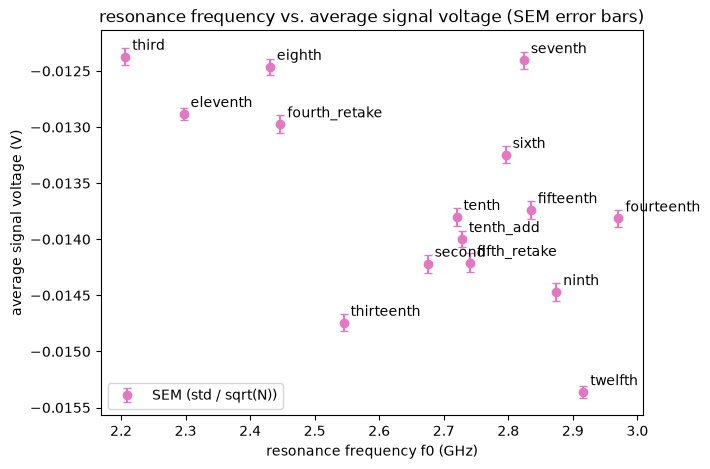

In [13]:
def plot_resonance_vs_voltage_sem(run_names=None):
    if run_names is None:
        run_names = find_run_names()

    f0s_ghz = []
    avg_voltages = []
    voltage_sems = []
    for run_name in run_names:
        result = _fine_sweep_result(run_name)
        seg_mean, _seg_std, _elapsed_s = _waveform_stats(run_name)
        sem = seg_mean.std() / np.sqrt(len(seg_mean))
        f0s_ghz.append(result["f0_hz"] / 1e9)
        avg_voltages.append(seg_mean.mean())
        voltage_sems.append(sem)
        print(f"{run_name}: f0 = {result['f0_hz']/1e9:.5f} GHz, "
              f"average voltage = {seg_mean.mean():.5f} +/- {sem:.6f} V (SEM, "
              f"N={len(seg_mean)})")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(f0s_ghz, avg_voltages, yerr=voltage_sems, fmt="o", color="C6", capsize=3,
                label="SEM (std / sqrt(N))")
    for name, x, y in zip(run_names, f0s_ghz, avg_voltages):
        ax.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
    ax.set_xlabel("resonance frequency f0 (GHz)")
    ax.set_ylabel("average signal voltage (V)")
    ax.set_title("resonance frequency vs. average signal voltage (SEM error bars)")
    ax.legend()
    plt.show()

    return list(zip(run_names, f0s_ghz, avg_voltages, voltage_sems))


_ = plot_resonance_vs_voltage_sem(
    ["second", "third", "fourth_retake", "fifth_retake", "sixth", "seventh", "eighth", "ninth", "tenth", "tenth_add", "eleventh", "twelfth", "thirteenth", "fourteenth", "fifteenth"]
)